In [19]:
from DFTStructureGenerator.descriptor import (
    DUPLICATE_CL_IDS,
    build_descriptor_maps,
    dataframe_to_descriptors,
    load_descriptor_maps,
    save_descriptor_maps,
)
import numpy as np
import pandas as pd
from DFTStructureGenerator.Build_DataBase import (
    B_TYPE_ORDER,
    CL_SUBSTRATE_TYPE_ORDER,
    LB_TYPE_ORDER,
    get_boron_type,
    get_cl_substrate_type,
    get_lb_type,
)
from DFTStructureGenerator.project_paths import CSV_DIR, DESCRIPTOR_DIR, FIGURE_DIR, TS_DATA_DIR, repo_path


## Reviewer Run Tags

- `[REVIEWER-RUNNABLE]`: can be run from files included in this repository, such as CSV, descriptor pickle, ASE database, Parquet, or existing figure inputs. No raw Gaussian working directory is required.
- `[RAW-GAUSSIAN/E:/work]`: depends on raw calculation artifacts, Gaussian logs, Mol files, ORCA/Gaussian input-output folders, or the external raw calculation root configured by `BORYLXAT_RAW_CALC_ROOT` (default `E:/work/B_Cl_Nu`). These cells document provenance but are not required for routine review reruns.
- `[OPTIONAL-DESCRIPTOR-GENERATION]`: regenerates descriptors from the released database. Reviewers can skip it and use the pre-extracted descriptor pickle files to save time.


In [20]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

np.random.seed(0)


In [22]:
from matplotlib import pyplot as plt
from DFTStructureGenerator.draw import (
    draw_correlation_map,
    plot_scatter_with_metrics,
)


In [23]:
duplicate_Cl_id = DUPLICATE_CL_IDS


In [24]:
DB_PATH = repo_path("BorylXAT-DB.db")
BN_CSV_PATH = CSV_DIR / "reactants_B_N.csv"
CL_CSV_PATH = CSV_DIR / "reactants_Cl.csv"
BN_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "BNdes_new2.pkl"
CL_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "Cldes_new2.pkl"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# Descriptor Generation [OPTIONAL-DESCRIPTOR-GENERATION]

Optional provenance/regeneration step. It rebuilds descriptor pickle files from the released `BorylXAT-DB.db` and CSV tables. Reviewers can skip these cells and start from **Feature Loading** to use `Data/descriptor/BNdes_new2.pkl` and `Data/descriptor/Cldes_new2.pkl` directly.


In [ ]:
B_N_des_map, Cl_des_map = build_descriptor_maps(
    db_path=DB_PATH,
    bn_csv_path=BN_CSV_PATH,
    cl_csv_path=CL_CSV_PATH,
    duplicate_cl_ids=duplicate_Cl_id,
)


In [ ]:
save_descriptor_maps(
    B_N_des_map,
    Cl_des_map,
    bn_path=BN_DESCRIPTOR_PATH,
    cl_path=CL_DESCRIPTOR_PATH,
)


# Feature Loading [REVIEWER-RUNNABLE]

Loads the pre-extracted descriptor pickle files supplied with the repository. This is the recommended fast path for reviewers.


In [ ]:
B_N_des_map, Cl_des_map = load_descriptor_maps(
    bn_path=BN_DESCRIPTOR_PATH,
    cl_path=CL_DESCRIPTOR_PATH,
)


# Training Model [REVIEWER-RUNNABLE]

Builds the CatBoost feature matrix from released descriptors and the released reaction CSV.


In [25]:
# Combined quantitative features used by the CatBoost barrier model.
data_csv = pd.read_csv(TS_DATA_DIR / "Borane_all.csv")
y = data_csv["deltaGa(kcal/mol)"].to_numpy()
all_Xs = dataframe_to_descriptors(
    data_csv,
    B_N_des_map,
    Cl_des_map,
    duplicate_cl_ids=duplicate_Cl_id,
)
all_X = np.asarray(all_Xs, dtype=float)


100%|██████████| 9237/9237 [00:00<00:00, 42722.00it/s]


In [26]:
all_X.shape


(9237, 18)

# Descriptor Correlation [REVIEWER-RUNNABLE]

Uses the loaded descriptors and target values only.


Max correlation:  0.8949314973189016


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0.724778,0.473933,0.386827,0.298085,0.260126,0.047863,0.040754,0.055555,0.420735,0.022419,0.008413,0.123982,0.097830,0.075731,0.135433,0.265516,0.020043,0.148533
1,0.473933,0.556387,0.854339,0.676388,0.214212,0.269248,0.279116,0.082657,0.650415,0.087656,0.206568,0.213885,0.066700,0.349582,0.102524,0.164597,0.240786,0.136265
2,0.386827,0.854339,0.481655,0.657325,0.246985,0.645349,0.086766,0.045805,0.624329,0.160090,0.201632,0.197606,0.075613,0.325185,0.113932,0.171168,0.218408,0.135405
3,0.298085,0.676388,0.657325,0.363935,0.087101,0.182580,0.452685,0.186613,0.404744,0.223725,0.191648,0.146920,0.115817,0.226762,0.035860,0.042567,0.188397,0.133241
4,0.260126,0.214212,0.246985,0.087101,0.247622,0.010012,0.661310,0.661367,0.676352,0.218041,0.126827,0.200974,0.015555,0.298888,0.111958,0.211373,0.204398,0.091730
5,0.047863,0.269248,0.645349,0.182580,0.010012,0.134692,0.134521,0.013284,0.095573,0.075867,0.034327,0.045035,0.008454,0.058789,0.085430,0.095918,0.018048,0.000550
6,0.040754,0.279116,0.086766,0.452685,0.661310,0.134521,0.049357,0.740696,0.253055,0.039026,0.000022,0.051032,0.049674,0.067684,0.073499,0.088547,0.062661,0.020120
7,0.055555,0.082657,0.045805,0.186613,0.661367,0.013284,0.740696,0.045117,0.392986,0.258911,0.070300,0.085552,0.014823,0.112889,0.053546,0.071031,0.094450,0.059757
8,0.420735,0.650415,0.624329,0.404744,0.676352,0.095573,0.253055,0.392986,0.426781,0.121339,0.281663,0.278724,0.095644,0.454057,0.162987,0.242322,0.313976,0.195190
9,0.022419,0.087656,0.160090,0.223725,0.218041,0.075867,0.039026,0.258911,0.121339,0.043261,0.016962,0.019022,0.024637,0.004197,0.058890,0.026670,0.001674,0.006539


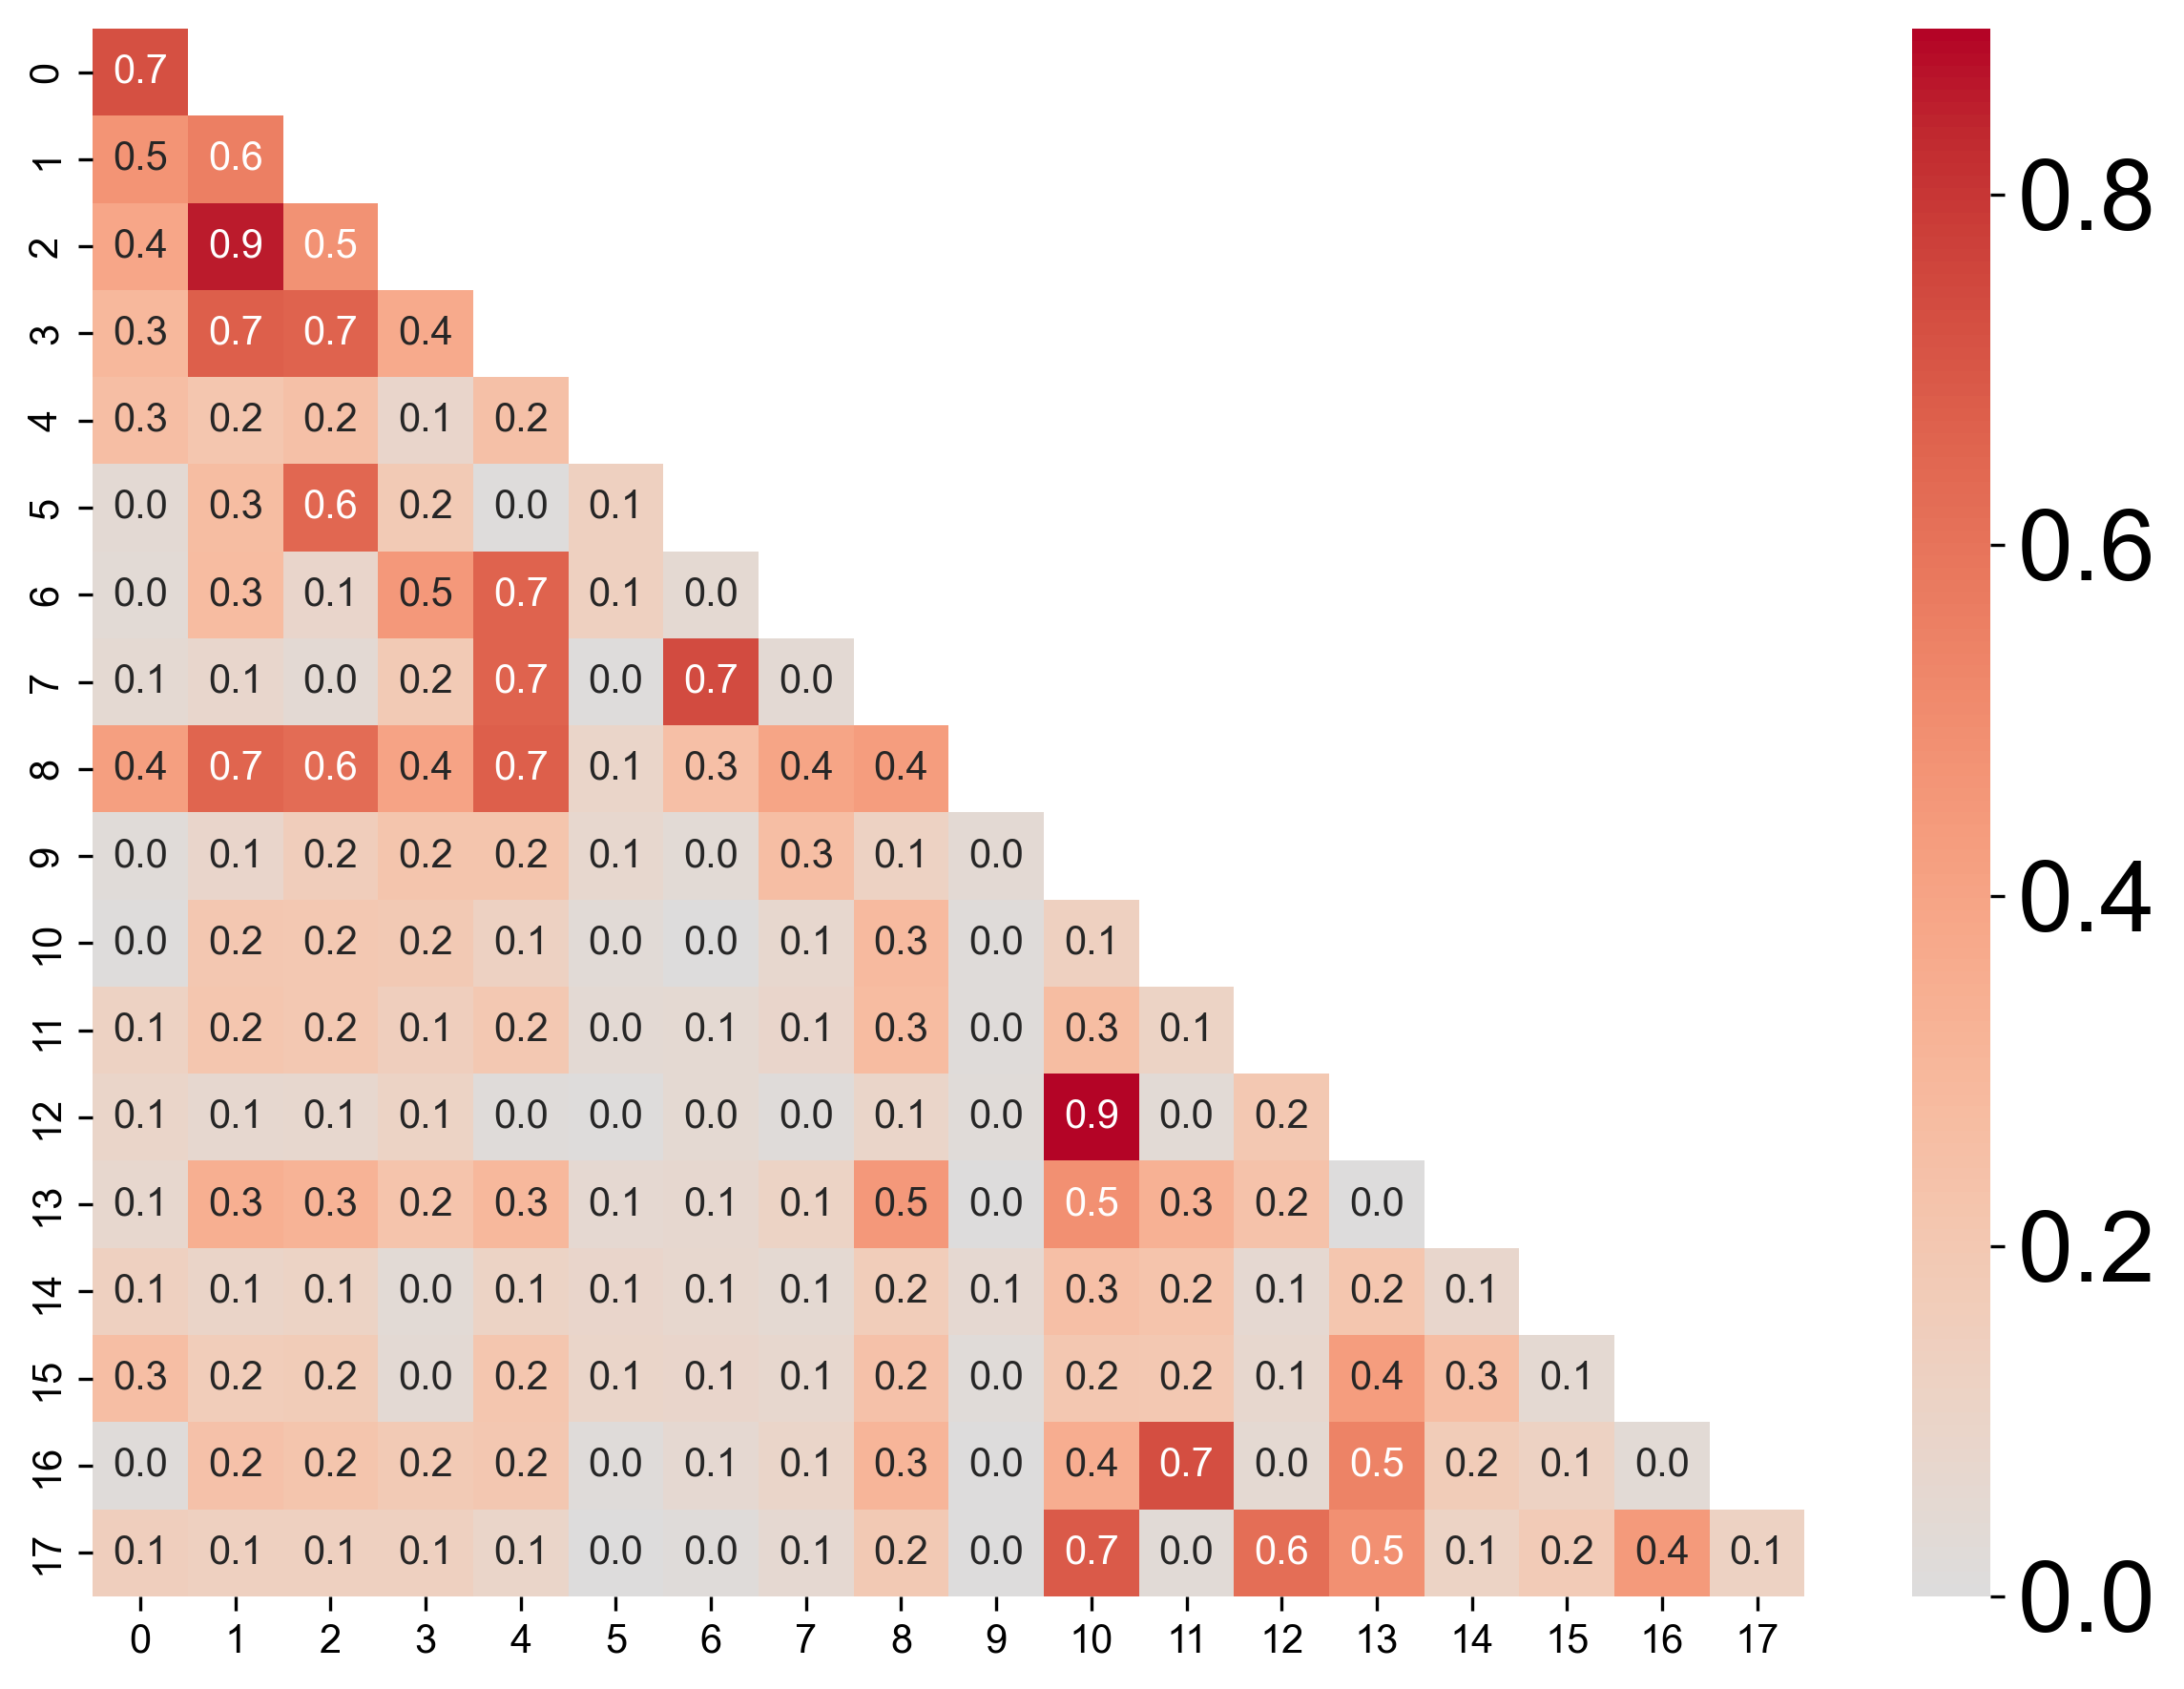

In [27]:
# Figure S21
descriptor_correlation_matrix = draw_correlation_map(
    all_X,
    figure_size=(8, 6),
    colors="coolwarm",
    annot=True,
    show_label=True,
    target=y,
)
plt.savefig(FIGURE_DIR / "FigureS21_descriptor_correlation_map.png", dpi=300, bbox_inches="tight")
descriptor_correlation_matrix


# 5-Fold Validation [REVIEWER-RUNNABLE]

Runs the reported random five-fold CatBoost validation from released descriptors.


In [29]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s = []
all_pred = np.zeros_like(y, dtype=float)

for train_ids, test_ids in kf.split(all_X):
    model = CatBoostRegressor(
        iterations=10000,
        learning_rate=0.01,
        depth=6,
        verbose=0,
        random_state=0,
    )
    model.fit(all_X[train_ids], y[train_ids])
    y_pred = model.predict(all_X[test_ids])

    fold_r2 = r2_score(y[test_ids], y_pred)
    fold_mae = mean_absolute_error(y[test_ids], y_pred)
    fold_mse = mean_squared_error(y[test_ids], y_pred)
    print(f"R2: {fold_r2:.3f}, MAE: {fold_mae:.3f}, MSE: {fold_mse:.3f}")

    all_r2s.append(fold_r2)
    all_pred[test_ids] = y_pred

print(f"Mean of 5-Fold R2: {np.mean(all_r2s):.3f}")


R2: 0.892, MAE: 1.415, MSE: 4.311
R2: 0.903, MAE: 1.430, MSE: 3.948
R2: 0.904, MAE: 1.404, MSE: 3.740
R2: 0.914, MAE: 1.338, MSE: 3.439
R2: 0.917, MAE: 1.370, MSE: 3.467
Mean of 5-Fold R2: 0.906


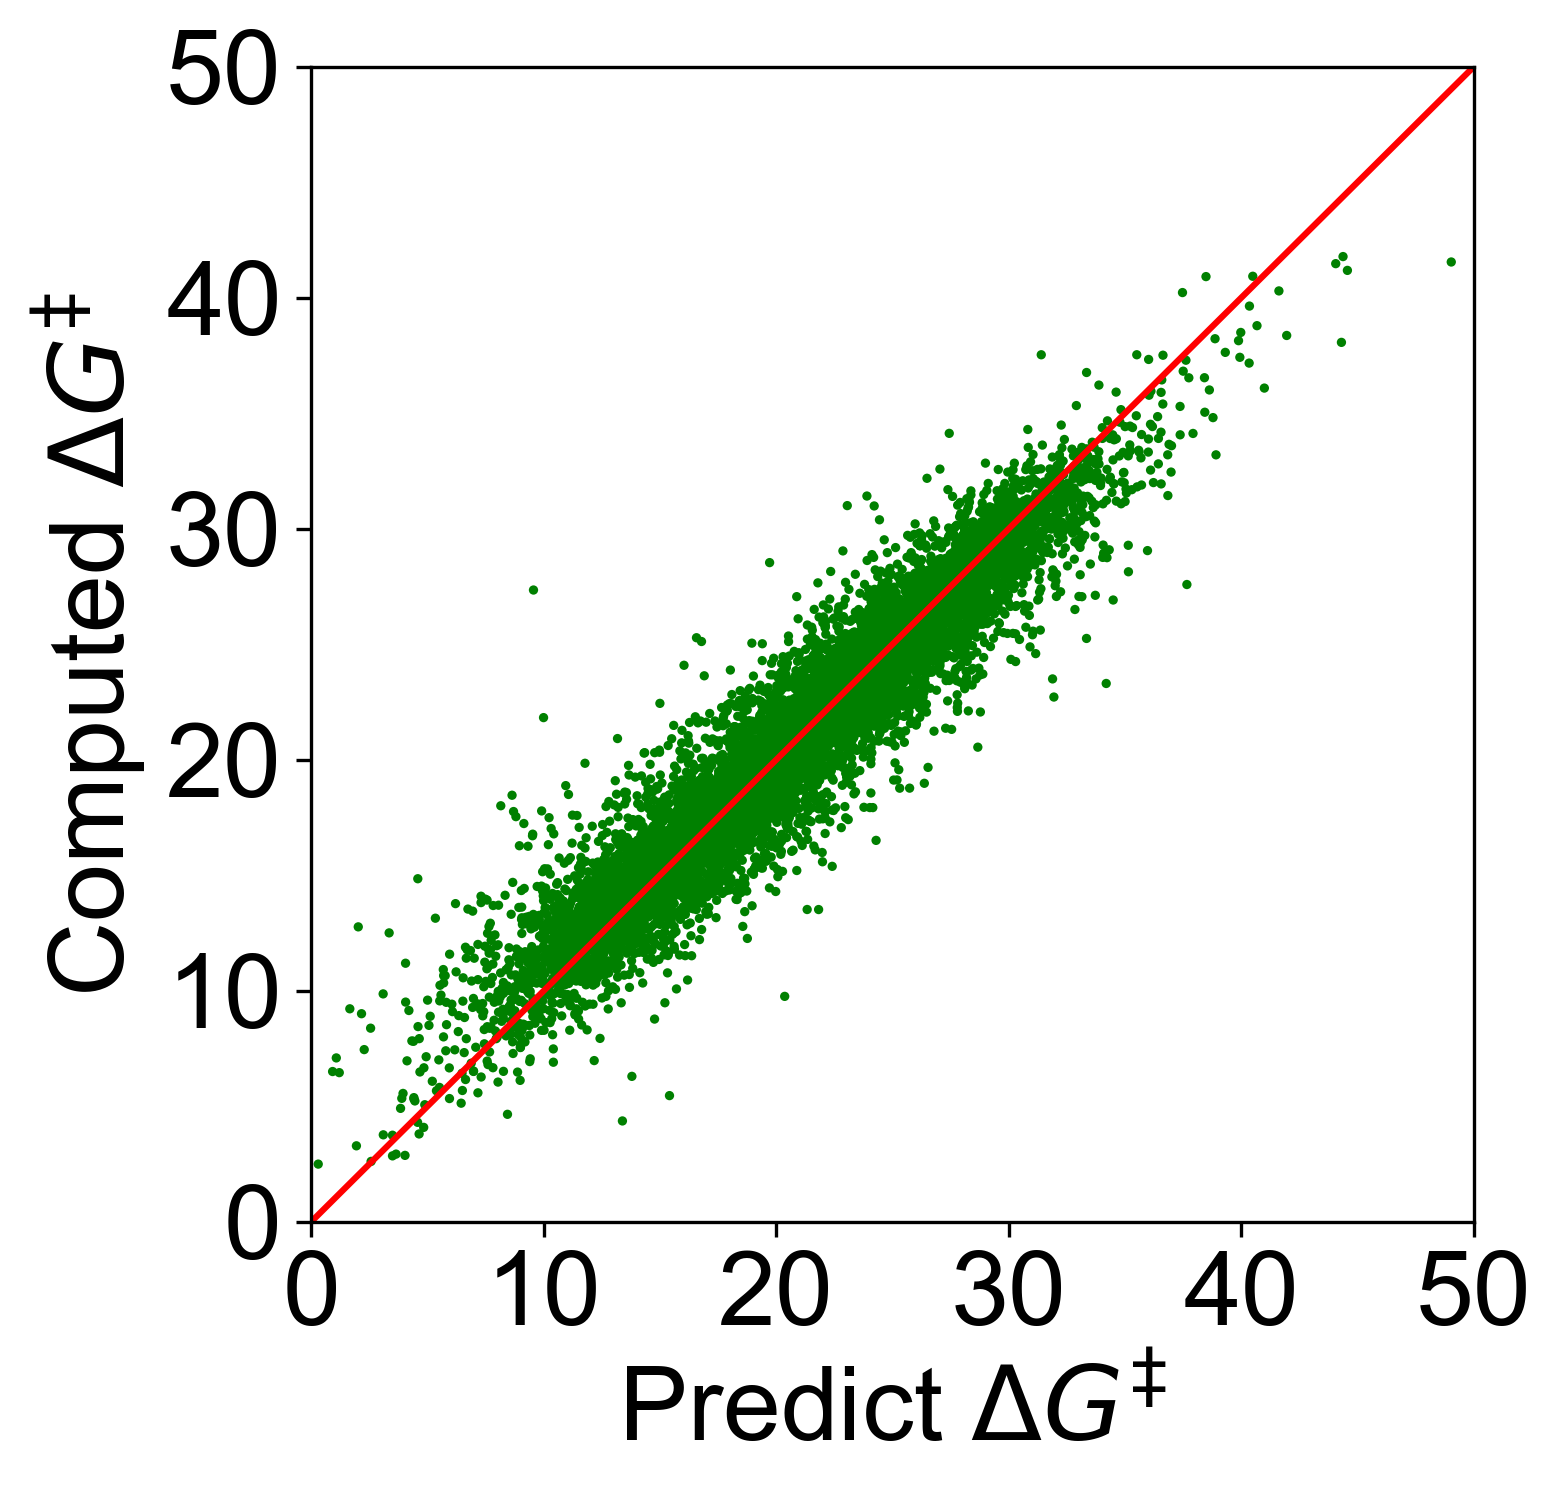

In [30]:
# Figure 6B
plot_scatter_with_metrics(
    y,
    all_pred,
    min_=0,
    max_=50,
    show=False,
)
plt.savefig(FIGURE_DIR / "Figure6B_model_validation.png", dpi=300, bbox_inches="tight")
plt.show()


In [32]:
model = CatBoostRegressor(
    iterations=10000,
    learning_rate=0.01,
    depth=6,
    verbose=0,
    random_state=0,
)
model.fit(all_X, y)
feature_importances = model.feature_importances_


In [33]:
des_name_std_sorted = [
    '$\\Delta G_{\\mathrm{rxn}}$',                 # deltaG
    'LB-B· $P^{\\mathrm{spin}}$',                  # B_N B_spin
    'LB-B· $q^{\\mathrm{B}}_{\\mathrm{H}}$',       # B_N B_Hirshfield_charge
    'LB-B· $d_{\\mathrm{LB-B}}$',                  # B_N B_N_dist
    'LB-B· $E_{\\mathrm{SOMO}}$',                  # B_N Alpha-HOMO
    'LB-B-Cl $q^{\\mathrm{B}}_{\\mathrm{H}}$',     # B_N_Cl B_Hirshfield_charge
    'LB-B-Cl $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',    # B_N_Cl Cl_Hirshfield_charge
    'LB-B· $d_{\\mathrm{B-Cl}}$',                  # B_N_Cl N_Cl_dist
    'LB-B-Cl $E_{\\mathrm{LUMO}}$',                # B_N_Cl LUMO
    'LB-B-Cl $\\%V_{\\mathrm{bur}}$',              # B_N_Cl Bv6radius
    'Cl-C $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',       # C_Cl Cl_Hirshfield_charge
    'Cl-C $q^{\\mathrm{C}}_{\\mathrm{H}}$',        # C_Cl C_Hirshfield_charge
    'Cl-C $d_{\\mathrm{Cl-C}}$',                   # C_Cl C_Cl_dist
    'Cl-C $E_{\\mathrm{LUMO}}$',                   # C_Cl LUMO
    'C_Cl $\\%V_{\\mathrm{bur}}$',                 # C_Cl Bv6radius
    'C· $P^{\\mathrm{spin}}$',                     # C C_spin
    'C· $q^{\\mathrm{C}}_{\\mathrm{H}}$',          # C C_Hirshfield_charge
    'C· $E_{\\mathrm{SOMO}}$'                      # C Alpha-HOMO
]

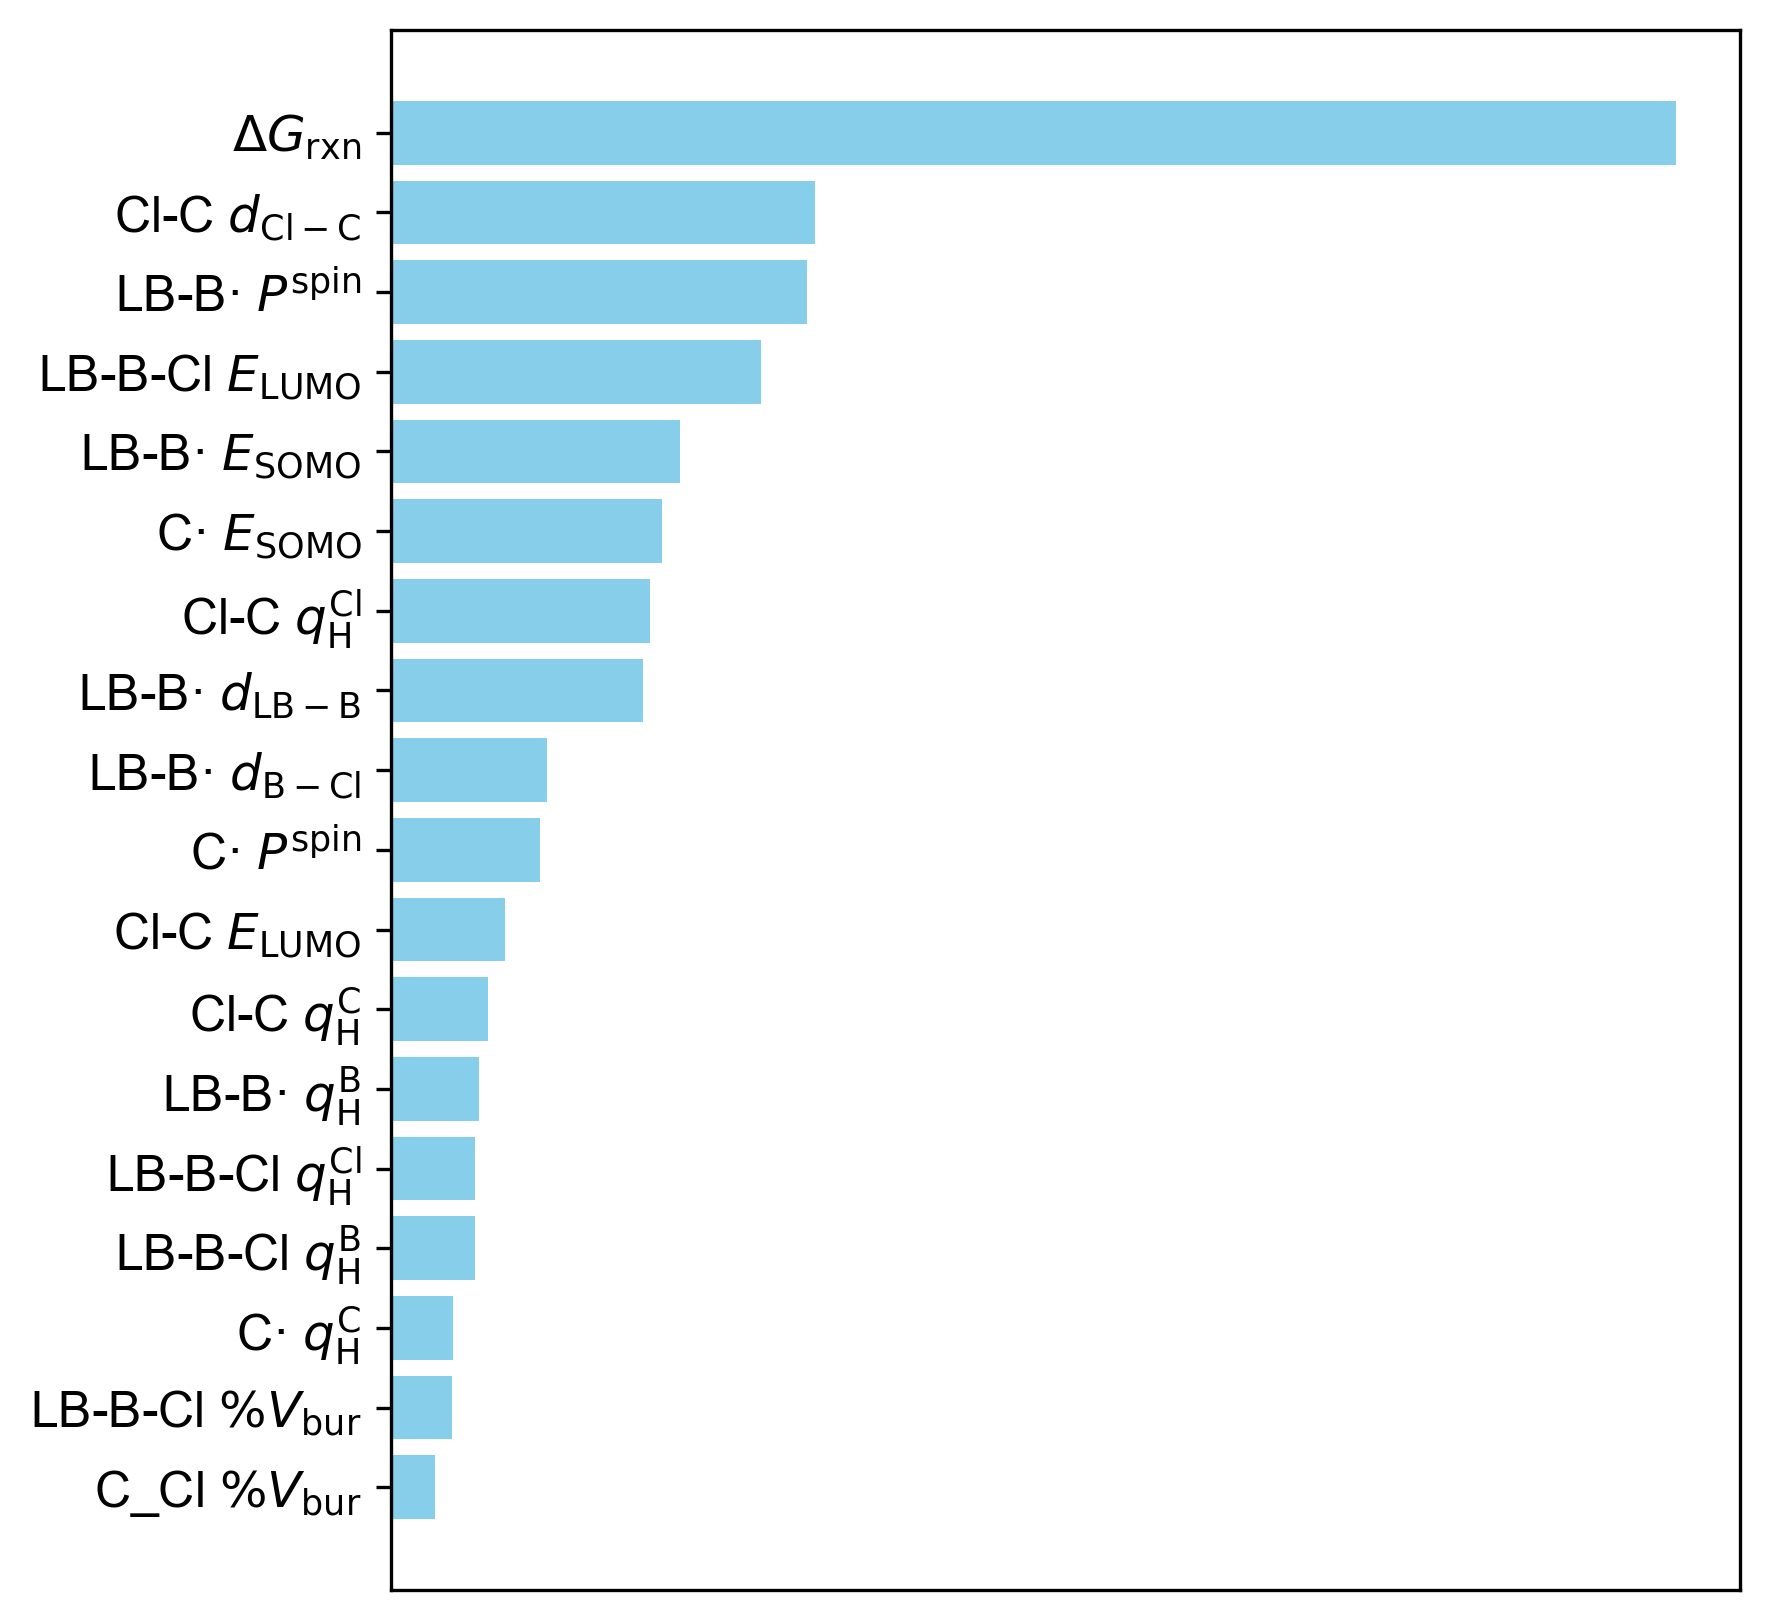

In [40]:
fig, ax = plt.subplots(figsize=(6, 5.5), dpi=300)
plt.rcParams["font.sans-serif"] = "Arial"
feature_order = np.argsort(feature_importances)
ax.barh(
    np.array(des_name_std_sorted)[feature_order],
    feature_importances[feature_order],
    color="skyblue",
)
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure6C_model_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


# Other Seeds [REVIEWER-RUNNABLE]

Optional robustness check using different random seeds; it is reviewer-runnable but more time-consuming than the main validation.


In [ ]:
all_X = np.asarray(all_Xs, dtype=float)
y = data_csv['deltaGa(kcal/mol)'].to_numpy()
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for seed in range(10):
    all_r2s, all_mae, all_mse = [], [], []
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    for train_ids, test_ids in list(kf.split(all_X)):
        model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state=0)
        # model = RandomForestRegressor()
        model.fit(all_X[train_ids], y[train_ids])
        y_pred = model.predict(all_X[test_ids])
        all_r2s.append(r2_score(y[test_ids], y_pred))
        all_mae.append(mean_absolute_error(y[test_ids], y_pred))
        all_mse.append(mean_squared_error(y[test_ids], y_pred))
    print(f"Seed: {seed}, R2: {np.mean(all_r2s):.3f}, MAE: {np.mean(all_mae):.3f}, MSE: {np.mean(all_mse):.3f}")

# OOD [REVIEWER-RUNNABLE]

Optional out-of-distribution validation from released descriptors and reaction metadata.


## OOD around Indexes [REVIEWER-RUNNABLE]

Component-index held-out validation; no raw Gaussian folders are required.


In [ ]:
def run_index_ood(
    data_df,
    index_column,
    label=None,
    n_splits=5,
    target_column="deltaGa(kcal/mol)",
    min_test_size=2,
):
    label = label or index_column
    index_values = np.sort(data_df[index_column].dropna().unique())
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)

    result_rows = []
    pred_rows = []
    for fold_id, (train_ids, test_ids) in enumerate(kf.split(index_values), start=1):
        train_values = index_values[train_ids]
        test_values = index_values[test_ids]
        train_df = data_df.loc[data_df[index_column].isin(train_values)].reset_index(drop=True)
        test_df = data_df.loc[data_df[index_column].isin(test_values)].reset_index(drop=True)
        if len(test_df) < min_test_size or len(train_df) == 0:
            continue

        train_X = dataframe_to_descriptors(
            train_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        test_X = dataframe_to_descriptors(
            test_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        train_y = train_df[target_column]
        test_y = test_df[target_column]

        model = CatBoostRegressor(
            iterations=10000,
            learning_rate=0.01,
            depth=6,
            verbose=0,
            random_state=0,
        )
        model.fit(train_X, train_y)
        y_pred = model.predict(test_X)

        result_rows.append({
            "OOD_axis": label,
            "fold": fold_id,
            "train_index_count": len(train_values),
            "test_index_count": len(test_values),
            "train_size": len(train_df),
            "test_size": len(test_df),
            "R2": r2_score(test_y, y_pred),
            "MAE": mean_absolute_error(test_y, y_pred),
            "MSE": mean_squared_error(test_y, y_pred),
        })
        pred_rows.extend(
            {
                "OOD_axis": label,
                "fold": fold_id,
                "y_true": y_true,
                "y_pred": pred,
            }
            for y_true, pred in zip(test_y.to_numpy(), y_pred)
        )

    return pd.DataFrame(result_rows), pd.DataFrame(pred_rows)


ood_index_configs = {
    "Cl_Index": "Cl_Index",
    "B_Index": "B_Index",
    "N_Index": "Nu_Index",
}
ood_index_results = {}
ood_index_predictions = {}

for index_column, label in ood_index_configs.items():
    result_df, pred_df = run_index_ood(data_csv, index_column=index_column, label=label)
    ood_index_results[label] = result_df
    ood_index_predictions[label] = pred_df

    print(f"OOD by {label}")
    display(result_df)
    if pred_df.empty:
        print(f"No valid OOD folds for {label}")
        continue
    print(
        "Mean fold R2:",
        result_df["R2"].mean(),
        "MAE:",
        result_df["MAE"].mean(),
    )
    print(
        "Overall R2:",
        r2_score(pred_df["y_true"], pred_df["y_pred"]),
        "MAE:",
        mean_absolute_error(pred_df["y_true"], pred_df["y_pred"]),
    )
    plot_scatter_with_metrics(
        pred_df["y_true"].to_numpy(),
        pred_df["y_pred"].to_numpy(),
        min_=0,
        max_=50,
    )


nonempty_ood_index_results = [
    result_df for result_df in ood_index_results.values() if not result_df.empty
]
if nonempty_ood_index_results:
    ood_index_summary = pd.concat(nonempty_ood_index_results, ignore_index=True)
else:
    ood_index_summary = pd.DataFrame()
display(ood_index_summary)


## OOD around Types [REVIEWER-RUNNABLE]

Component-type held-out validation; no raw Gaussian folders are required.


In [ ]:
def add_ood_type_columns(df):
    typed_df = df.copy()
    typed_df["B_type"] = typed_df["B_smiles"].map(get_boron_type)
    typed_df["Nu_type"] = typed_df["N_Index"].map(get_lb_type)
    typed_df["Cl_type"] = typed_df["Cl_smiles"].map(get_cl_substrate_type)
    return typed_df


def run_type_ood(
    typed_df,
    type_column,
    type_order=None,
    target_column="deltaGa(kcal/mol)",
    min_test_size=2,
):
    if type_order is None:
        type_order = sorted(typed_df[type_column].dropna().unique())

    result_rows = []
    pred_rows = []
    for heldout_type in type_order:
        test_df = typed_df.loc[typed_df[type_column] == heldout_type].reset_index(drop=True)
        train_df = typed_df.loc[typed_df[type_column] != heldout_type].reset_index(drop=True)
        if len(test_df) < min_test_size or len(train_df) == 0:
            continue

        train_X = dataframe_to_descriptors(
            train_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        test_X = dataframe_to_descriptors(
            test_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        train_y = train_df[target_column]
        test_y = test_df[target_column]

        model = CatBoostRegressor(
            iterations=10000,
            learning_rate=0.01,
            depth=6,
            verbose=0,
            random_state=0,
        )
        model.fit(train_X, train_y)
        y_pred = model.predict(test_X)

        result_rows.append({
            "OOD_axis": type_column,
            "heldout_type": heldout_type,
            "train_size": len(train_df),
            "test_size": len(test_df),
            "R2": r2_score(test_y, y_pred),
            "MAE": mean_absolute_error(test_y, y_pred),
            "MSE": mean_squared_error(test_y, y_pred),
        })
        pred_rows.extend(
            {
                "OOD_axis": type_column,
                "heldout_type": heldout_type,
                "y_true": y_true,
                "y_pred": pred,
            }
            for y_true, pred in zip(test_y.to_numpy(), y_pred)
        )

    return pd.DataFrame(result_rows), pd.DataFrame(pred_rows)


data_csv_typed = add_ood_type_columns(data_csv)
ood_type_counts = {
    "B_type": data_csv_typed["B_type"].value_counts().reindex(B_TYPE_ORDER).dropna().astype(int),
    "Nu_type": data_csv_typed["Nu_type"].value_counts().reindex(LB_TYPE_ORDER).dropna().astype(int),
    "Cl_type": data_csv_typed["Cl_type"].value_counts().reindex(CL_SUBSTRATE_TYPE_ORDER).dropna().astype(int),
}
for axis_name, counts in ood_type_counts.items():
    print(f"{axis_name} counts:")
    print(counts.to_string())
    print()


ood_type_results = {}
ood_type_predictions = {}
ood_type_configs = {
    "B_type": B_TYPE_ORDER,
    "Nu_type": LB_TYPE_ORDER,
    "Cl_type": CL_SUBSTRATE_TYPE_ORDER,
}

for type_column, type_order in ood_type_configs.items():
    result_df, pred_df = run_type_ood(
        data_csv_typed,
        type_column=type_column,
        type_order=type_order,
    )
    ood_type_results[type_column] = result_df
    ood_type_predictions[type_column] = pred_df

    print(f"OOD by {type_column}")
    display(result_df)
    if pred_df.empty:
        print(f"No valid OOD folds for {type_column}")
        continue
    print(
        "Overall R2:",
        r2_score(pred_df["y_true"], pred_df["y_pred"]),
        "MAE:",
        mean_absolute_error(pred_df["y_true"], pred_df["y_pred"]),
    )
    plot_scatter_with_metrics(
        pred_df["y_true"].to_numpy(),
        pred_df["y_pred"].to_numpy(),
        min_=0,
        max_=50,
    )


nonempty_ood_type_results = [
    result_df for result_df in ood_type_results.values() if not result_df.empty
]
if nonempty_ood_type_results:
    ood_type_summary = pd.concat(nonempty_ood_type_results, ignore_index=True)
else:
    ood_type_summary = pd.DataFrame()
display(ood_type_summary)
